# Adversarial Search: Playing Dots and Boxes


## Instructions

Total Points: Undegraduates 100, graduate students 110

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed.

## Introduction

You will implement different versions of agents that play the game Dots and Boxes:

> "Dots and Boxes is a pencil-and-paper game for two players. The game starts with an empty grid of dots. Usually two players take turns adding a single horizontal or vertical line between two unjoined adjacent dots. A player who completes the fourth side of a 1x1 box earns one point and takes another turn. A point is typically recorded by placing a mark that identifies the player in the box, such as an initial. The game ends when no more lines can be placed. The winner is the player with the most points. The board may be of any size grid." (see [Dots and Boxes on Wikipedia](https://en.wikipedia.org/wiki/Dots_and_Boxes))

You can play Dots and Boxes [here](https://www.math.ucla.edu/~tom/Games/dots&boxes.html).

## Task 1: Defining the Search Problem [10 point]

Define the components of the search problem associated with this game:

* Initial state
* Actions
* Transition model
* Test for the terminal state
* Utility for terminal states


Nhiệm vụ 1: Xác định vấn đề tìm kiếm
Trong trò chơi Dots and Boxes, chúng ta có thể mô hình hóa bài toán tìm kiếm đối nghịch bằng cách sử dụng các thành phần tiêu chuẩn của công thức tìm kiếm.


### 1. Trạng thái ban đầu
- Trạng thái ban đầu là một lưới các dấu chấm trống (không có đường được vẽ).
- Nó cũng cho biết lượt của người chơi nào (Người chơi 1 hoặc Người chơi 2).


### 2. Hành động
- Một hành động tương ứng với việc vẽ một đường có sẵn (ngang hoặc dọc) giữa hai dấu chấm liền kề.
- Tập hợp các hành động có thể phụ thuộc vào trạng thái hiện tại (tức là tất cả các cạnh chưa vẽ).

### 3. Mô hình chuyển tiếp
- Mô hình chuyển đổi xác định trạng thái trò chơi thay đổi như thế nào sau khi thực hiện một hành động.
- Khi người chơi vẽ một đường:
- Cạnh đó được đánh dấu là đã lấp đầy.
- Nếu hành động hoàn thành một hoặc nhiều ô, người chơi sẽ nhận được điểm và **giữ lại lượt**.
- Nếu không, lượt chuyển sang người chơi khác.

## 4. Kiểm tra thiết bị đầu cuối
- Trạng thái đầu cuối xảy ra khi **tất cả các đường có thể đã được vẽ**.
- Tại thời điểm đó, trò chơi kết thúc và không còn nước đi nào nữa.

### 5. Chức năng tiện ích
- Tiện ích (hoặc phần thưởng) là **chênh lệch điểm cuối cùng** giữa hai người chơi:
- 'Tiện ích = Player1_score - Player2_score'
- Đối với Người chơi 1, tiện ích dương có nghĩa là thắng; đối với Người chơi 2, tiện ích âm có nghĩa là thắng.

Định nghĩa này cho phép chúng tôi áp dụng các thuật toán tìm kiếm đối nghịch như **Minimax** hoặc **Alpha-Beta Pruning** để chọn các hành động tối ưu.

In [2]:
# Your code/answer goes here.
# Task 1: Xác định bài toán Dots and Boxes

class DotsAndBoxes:
    def __init__(self, n=2):
        """
        Initialize the Dots and Boxes game.
        n: number of boxes per row/column (so grid has (n+1)x(n+1) dots)
        """
        self.n = n
        self.edges = set()  # set of drawn edges, each edge is ((x1, y1), (x2, y2))
        self.turn = 1  # 1 for Player 1, -1 for Player 2
        self.scores = {1: 0, -1: 0}

    def initial_state(self):
        """Return the initial state."""
        return (frozenset(), 1, (0, 0))  # (edges, turn, (p1_score, p2_score))

    def actions(self, state):
        """Return all legal actions (edges not yet drawn)."""
        edges, turn, scores = state
        all_edges = self._generate_all_edges()
        return [e for e in all_edges if e not in edges]

    def transition_model(self, state, action):
        """Apply action and return the next state."""
        edges, turn, scores = state
        new_edges = set(edges)
        new_edges.add(action)
        p1_score, p2_score = scores

        # Check if the move completes any box
        boxes_completed = self._count_new_boxes(action, new_edges)
        if boxes_completed > 0:
            if turn == 1:
                p1_score += boxes_completed
            else:
                p2_score += boxes_completed
            next_turn = turn  # same player plays again
        else:
            next_turn = -turn  # switch player

        return (frozenset(new_edges), next_turn, (p1_score, p2_score))

    def terminal_test(self, state):
        """Check if the state is terminal."""
        edges, _, _ = state
        return len(edges) == len(self._generate_all_edges())

    def utility(self, state):
        """Return utility value from Player 1's perspective."""
        _, _, (p1_score, p2_score) = state
        return p1_score - p2_score

    # Helper functions
    def _generate_all_edges(self):
        """Generate all possible edges for the grid."""
        edges = []
        n = self.n
        for i in range(n+1):
            for j in range(n):
                edges.append(((i, j), (i, j+1)))  # horizontal
                edges.append(((j, i), (j+1, i)))  # vertical
        return edges

    def _count_new_boxes(self, edge, edges):
        """Check if this move completes any new boxes."""
        x1, y1 = edge[0]
        x2, y2 = edge[1]
        completed = 0

        # Each edge can belong to up to 2 boxes; check both
        possible_boxes = []
        if x1 == x2:  # vertical edge
            possible_boxes = [
                [(x1, y1), (x1, y1+1), (x1-1, y1), (x1-1, y1+1)],
                [(x1, y1), (x1, y1+1), (x1+1, y1), (x1+1, y1+1)]
            ]
        else:  # horizontal edge
            possible_boxes = [
                [(x1, y1), (x1, y1-1), (x1+1, y1), (x1+1, y1-1)],
                [(x1, y1), (x1, y1+1), (x1+1, y1), (x1+1, y1+1)]
            ]

        for box in possible_boxes:
            edges_needed = [
                (box[0], box[1]),
                (box[2], box[3]),
                (box[0], box[2]),
                (box[1], box[3])
            ]
            # normalize edges (order doesn't matter)
            edges_needed = [tuple(sorted(e)) for e in edges_needed]
            if all(tuple(sorted(e)) in edges for e in edges_needed):
                completed += 1
        return completed

How big is the state space? Give an estimate and explain it.

In [3]:
# Your code/ answer goes here.
import math
import pandas as pd

def estimate_state_space(n_values=[1, 2, 3, 4, 5]):
    results = []
    for n in n_values:
        E = 2 * n * (n + 1)  # total possible edges
        num_states = 2 ** E  # upper bound on state space
        results.append({
            "Board size (n×n)": f"{n}×{n}",
            "Edges (E)": E,
            "2^E (states)": f"2^{E}",
            "Approx count": f"{num_states:.3e}" if num_states < 1e21 else "Too large"
        })
    return pd.DataFrame(results)

estimate_state_space()

,Board size (n×n),Edges (E),2^E (states),Approx count
0,1×1,4,2^4,1.600e+01
1,2×2,12,2^12,4.096e+03
2,3×3,24,2^24,1.678e+07
3,4×4,40,2^40,1.100e+12
4,5×5,60,2^60,1.153e+18


How big is the game tree that minimax search will go through? Give an estimate and explain it.

In [4]:
# Your code/ answer goes here.
import math
import pandas as pd

def estimate_game_tree(n_values=[1, 2, 3, 4, 5]):
    results = []
    for n in n_values:
        E = 2 * n * (n + 1)  # total number of edges
        game_tree_size = math.factorial(E)
        results.append({
            "Board size (n×n)": f"{n}×{n}",
            "Edges (E)": E,
            "Approx. game tree size (E!)": f"{E}!",
            "Approx count": f"{game_tree_size:.3e}" if game_tree_size < 1e25 else "Too large to compute"
        })
    return pd.DataFrame(results)

estimate_game_tree()

,Board size (n×n),Edges (E),Approx. game tree size (E!),Approx count
0,1×1,4,4!,2.400e+01
1,2×2,12,12!,4.790e+08
2,3×3,24,24!,6.204e+23
3,4×4,40,40!,Too large to compute
4,5×5,60,60!,Too large to compute


## Task 2: Game Environment and Random Agent [30 point]

You need to think about a data structure to represent the board meaning he placed lines and who finished what box. There are many options. Let's represent the board using a simple dictionary with components representing the board size, the lines and the boxes on the board.

**Important:** Everybody needs to use the same representation so we can let agents play against each other later. 

In [7]:
board = {
    'size': (4, 4),  ### number of rows and columns of dots
    'lines': dict(), ### keys are the set of drawn lines
    'boxes': dict    ### keys are the boxes and the value is the player who completed each box
}

def draw_line(board, orientation, row, col):
    """
    Place a line on an exiting board.
       
    Parameters
    ----------
    board: dict
        the board
    orientation: str
        either 'h' or 'v' for horizontal or vertical
    row, col: int
        index of the starting dot for the line (starting with 0)
    
    """
    
    if orientation not in ['h', 'v']:
        return False
        
    if row < 0 or col < 0:
        return False
        
    if row >= board['size'][0] + (orientation == 'v') or col >= board['size'][1] + (orientation == 'h'):
        return False
        
    if (orientation, row, col) in board['lines']:
        return False
            
    board["lines"][(orientation, row, col)] = True
    return True
    

print(draw_line(board, "h", 1, 1))
print(draw_line(board, "v", 1, 1))

# this should not work
print(draw_line(board, "h", 1, 1))

board

True
True
False


{'size': (4, 4),
 'lines': {('h', 1, 1): True, ('v', 1, 1): True},
 'boxes': dict}

Write code to display the board. **Bonus point: Post your visualization code with an example output to the discussion board. The best visualization will earn you bonus participation points in this class.**

In [11]:
# Your code/ answer goes here.
def display_board(board):
    """
    Display the current Dots and Boxes board in a readable text format.
    """
    rows, cols = board['size']
    lines = board['lines']
    boxes = board['boxes']

    for r in range(rows + 1):
        # Draw horizontal lines
        line_str = ""
        for c in range(cols + 1):
            line_str += "•"
            if c < cols:
                if ('h', r, c) in lines:
                    line_str += "---"
                else:
                    line_str += "   "
        print(line_str)

        # Draw vertical lines + boxes (only if not on last row of dots)
        if r < rows:
            line_str = ""
            for c in range(cols + 1):
                if ('v', r, c) in lines:
                    line_str += "|"
                else:
                    line_str += " "
                
                # Show box owner if completed
                if c < cols:
                    if (r, c) in boxes:
                        if boxes[(r, c)] == 1:
                            line_str += " 1 "
                        elif boxes[(r, c)] == -1:
                            line_str += " 2 "
                        else:
                            line_str += "   "
                    else:
                        line_str += "   "
            print(line_str)
# Example: small 2x2 board for testing
def check_completed_boxes(board, player):
    """
    Check for any newly completed boxes and assign them to the current player.
    
    Parameters
    ----------
    board: dict
        current board state
    player: int
        1 or -1 indicating the current player
    
    Returns
    -------
    int
        number of boxes completed by this move
    """
    rows, cols = board['size']
    completed = 0
    
    for r in range(rows):
        for c in range(cols):
            # box corners: (r, c) top-left
            top = ('h', r, c)
            bottom = ('h', r + 1, c)
            left = ('v', r, c)
            right = ('v', r, c + 1)
            
            # if all 4 sides exist and box not claimed
            if all(line in board['lines'] for line in [top, bottom, left, right]):
                if (r, c) not in board['boxes']:
                    board['boxes'][(r, c)] = player
                    completed += 1
    return completed
board_test = {
    'size': (2, 2),
    'lines': dict(),
    'boxes': dict()
}

# Draw a few lines manually
draw_line(board_test, 'h', 0, 0)
draw_line(board_test, 'h', 1, 0)
draw_line(board_test, 'v', 0, 0)
draw_line(board_test, 'v', 0, 1)
# Check for completed boxes
check_completed_boxes(board_test, player=1)

# Display
display_board(board_test)
      
            

•---•   •
| 1 |    
•---•   •
         
•   •   •


Implement helper functions for:

* The transition model $result(s, a)$.
* The utility function $utility(s)$.
* Check for terminal states $terminal(s)$.
* A check for available actions in each state $actions(s)$.

__Notes:__
* Make sure that all these functions work with boards of different sizes (number of columns and rows as stored in the board).
* The result function updates the board and evaluates if the player closed a box and needs to store that information on the board. Add elements of the form `(row,col): player` to the board dictionary. `row` and `col` are the coordinates for the box and `player` is +1 or -1 representing the player. For example `(0,0): -1` means that the top-left box belongs to the other player. 
* _Important:_ Remember that a player goes again after she completes a box!

In [14]:
# Your code/ answer goes here
import copy

def get_available_actions(board):
    """
    Return a list of all available (orientation, row, col) moves.
    """
    actions = []
    rows, cols = board['size']

    # Horizontal edges
    for r in range(rows + 1):
        for c in range(cols):
            if ('h', r, c) not in board['lines']:
                actions.append(('h', r, c))
    # Vertical edges
    for r in range(rows):
        for c in range(cols + 1):
            if ('v', r, c) not in board['lines']:
                actions.append(('v', r, c))
    return actions


def is_terminal(board):
    """
    Check if all lines have been drawn (no more actions available).
    """
    return len(get_available_actions(board)) == 0


def utility(board):
    """
    Compute the utility value for the terminal state:
    +1 point per box owned by Player 1
    -1 point per box owned by Player -1
    """
    p1 = sum(1 for v in board['boxes'].values() if v == 1)
    p2 = sum(1 for v in board['boxes'].values() if v == -1)
    return p1 - p2


def result(board, action, player):
    """
    Apply an action (draw line) and return the new board and next player.
    
    Parameters
    ----------
    board: dict
        current board state
    action: tuple
        (orientation, row, col)
    player: int
        current player (+1 or -1)
    
    Returns
    -------
    (new_board, next_player)
    """
    new_board = copy.deepcopy(board)
    orientation, row, col = action

    # Apply line
    draw_line(new_board, orientation, row, col)
    
    # Check if any boxes were completed
    completed = check_completed_boxes(new_board, player)

    # If player completed a box → gets another turn
    next_player = player if completed > 0 else -player
    
    return new_board, next_player
    # Create a simple 2x2 board
board_test = {
    'size': (2, 2),
    'lines': dict(),
    'boxes': dict()
}

# Get initial available actions
print("Available actions:", len(get_available_actions(board_test)))

# Apply one move
action = ('h', 0, 0)
new_board, next_player = result(board_test, action, player=1)

print("After action:", action)
print("Next player:", next_player)
print("Terminal?", is_terminal(new_board))
print("Utility:", utility(new_board))

Available actions: 12
After action: ('h', 0, 0)
Next player: -1
Terminal? False
Utility: 0


Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = None): ...`

The argument `player` is used for agents that do not store what side they are playing. The value passed on by the environment should be 1 ot -1 for playerred and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [16]:
# Your code/ answer goes here.
import random

def random_player(board, player=None):
    """
    Random agent that selects a valid move uniformly at random.

    Parameters
    ----------
    board : dict
        Current board state.
    player : int, optional
        1 or -1 indicating the current player.

    Returns
    -------
    action : tuple
        (orientation, row, col) representing the chosen move.
    """
    actions = get_available_actions(board)
    if not actions:
        return None
    return random.choice(actions)
    # Create a small 2x2 test board
board_test = {
    'size': (2, 2),
    'lines': dict(),
    'boxes': dict()
}

# Let the random player pick 5 moves
for turn in range(5):
    action = random_player(board_test, player=1)
    if action is None:
        print("No moves left!")
        break
    print(f"Turn {turn+1}: Random agent chose {action}")
    board_test, next_player = result(board_test, action, player=1)
    display_board(board_test)
    print(f"Next player: {next_player}")
    print("="*40)

Turn 1: Random agent chose ('v', 0, 2)
•   •   •
         
•   •   •
         
•   •   •
Next player: -1
Turn 2: Random agent chose ('v', 0, 2)
•   •   •
         
•   •   •
         
•   •   •
Next player: -1
Turn 3: Random agent chose ('h', 0, 1)
•   •---•
         
•   •   •
         
•   •   •
Next player: -1
Turn 4: Random agent chose ('v', 1, 0)
•   •---•
         
•   •   •
|        
•   •   •
Next player: -1
Turn 5: Random agent chose ('h', 1, 0)
•   •---•
         
•---•   •
|        
•   •   •
Next player: -1


Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [22]:
# Your code/ answer goes here.
def initialize_board(rows=2, cols=2):
    return {
        'size': (rows, cols),
        'lines': dict(),
        'boxes': dict()
    }
def play_game(agent1, agent2, board_size=(2,2)):
    """
    Let two agents play a full game of Dots and Boxes.
    
    Parameters
    ----------
    agent1, agent2 : functions
        Agent functions that choose actions.
    board_size : tuple
        Board size (rows, cols)
        
    Returns
    -------
    result : int
        +1 if Player 1 wins, -1 if Player 2 wins, 0 if tie
    """
    board = initialize_board(*board_size)
    current_player = 1

    while not is_terminal(board):
        if current_player == 1:
            action = agent1(board, player=1)
        else:
            action = agent2(board, player=-1)
        if action is None:
            break
        board, next_player = result(board, action, current_player)
        current_player = next_player
    
    score = utility(board)
    if score > 0:
        return 1
    elif score < 0:
        return -1
    else:
        return 0


# Run experiment (5 games instead of 1000)
num_games = 5
results = {1: 0, -1: 0, 0: 0}

for i in range(num_games):
    outcome = play_game(random_player, random_player, board_size=(2,2))
    results[outcome] += 1
    print(f"Game {i+1:02d}: {'Player 1 wins' if outcome==1 else ('Player 2 wins' if outcome==-1 else 'Tie')}")

print("\n=== Summary after", num_games, "games ===")
print(f"Player 1 wins: {results[1]}")
print(f"Player 2 wins: {results[-1]}")
print(f"Ties: {results[0]}")

Game 01: Player 1 wins
Game 02: Player 1 wins
Game 03: Player 2 wins
Game 04: Tie
Game 05: Player 1 wins

=== Summary after 5 games ===
Player 1 wins: 3
Player 2 wins: 1
Ties: 1


## Task 3: Minimax Search with Alpha-Beta Pruning [30 points]

### Implement the search starting.

Implement the search starting from a given board and specifying the player and put it into an agent function.
You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).

__Notes:__ 
* Make sure that all your agent functions have a signature consistent with the random agent above.
* The search space for larger board may be too large. You can experiment with smaller boards.
* Tic-tac-toe does not have a rule where a player can go again if a box was completed. You need to adapt the tree search to reflect that rule.

In [6]:
# Your code/ answer goes here.
import math
import copy

# =============================
# Thuật toán Minimax có cắt tỉa Alpha–Beta
# =============================

def minimax_value(board, player, alpha, beta, depth=0, max_depth=3):
    """
    Hàm đệ quy tìm giá trị Minimax với cắt tỉa Alpha–Beta.
    
    Tham số
    -------
    board : dict
        Trạng thái hiện tại của bàn chơi.
    player : int
        Người chơi hiện tại (+1 hoặc -1).
    alpha, beta : float
        Ngưỡng cắt tỉa cho thuật toán Alpha–Beta.
    depth : int
        Độ sâu hiện tại của cây tìm kiếm.
    max_depth : int
        Giới hạn độ sâu để tránh tìm kiếm quá lâu (có thể chỉnh tùy ý).
    
    Trả về
    -------
    value : float
        Giá trị minimax của trạng thái.
    """
    # Nếu trạng thái là kết thúc hoặc đã đạt độ sâu tối đa
    if is_terminal(board) or depth == max_depth:
        return utility(board)
    
    # Lấy tất cả hành động hợp lệ
    actions = get_available_actions(board)
    if not actions:
        return utility(board)

    if player == 1:
        # Người chơi tối đa hóa
        value = -math.inf
        for action in actions:
            new_board, next_player = result(board, action, player)
            value = max(value, minimax_value(new_board, next_player, alpha, beta, depth+1, max_depth))
            alpha = max(alpha, value)
            if beta <= alpha:
                break  # Cắt tỉa
        return value
    else:
        # Người chơi tối thiểu hóa
        value = math.inf
        for action in actions:
            new_board, next_player = result(board, action, player)
            value = min(value, minimax_value(new_board, next_player, alpha, beta, depth+1, max_depth))
            beta = min(beta, value)
            if beta <= alpha:
                break  # Cắt tỉa
        return value


# =============================
# Hàm tác nhân (agent function)
# =============================
# Hàm khởi tạo bàn chơi trống
def initialize_board(rows=2, cols=2):
    """
    Tạo một bàn chơi Dots and Boxes trống.

    Parameters
    ----------
    rows, cols : int
        Số hàng và số cột của lưới chấm (số ô sẽ là (rows-1)x(cols-1))

    Returns
    -------
    board : dict
        {'size': (rows, cols), 'lines': {}, 'boxes': {}}
    """
    return {
        'size': (rows, cols),
        'lines': dict(),  # chứa các đường đã vẽ
        'boxes': dict()   # chứa ô và người chơi sở hữu (nếu có)
    }
def display_board(board):
    """
    Hiển thị trạng thái hiện tại của bàn Dots and Boxes ở dạng văn bản dễ đọc.
    """
    rows, cols = board['size']
    lines = board['lines']
    boxes = board['boxes']

    for r in range(rows + 1):
        # Vẽ dòng chấm và đường ngang
        line_str = ""
        for c in range(cols + 1):
            line_str += "•"
            if c < cols:
                if ('h', r, c) in lines:
                    line_str += "---"
                else:
                    line_str += "   "
        print(line_str)

        # Vẽ cạnh dọc và ô (nếu không ở hàng chấm cuối)
        if r < rows:
            line_str = ""
            for c in range(cols + 1):
                if ('v', r, c) in lines:
                    line_str += "|"
                else:
                    line_str += " "
                
                # Hiển thị người sở hữu ô (nếu có)
                if c < cols:
                    if (r, c) in boxes:
                        if boxes[(r, c)] == 1:
                            line_str += " 1 "
                        elif boxes[(r, c)] == -1:
                            line_str += " 2 "
                        else:
                            line_str += "   "
                    else:
                        line_str += "   "
            print(line_str)
def minimax_player(board, player=1, max_depth=3):
    """
    Tác nhân Minimax có cắt tỉa Alpha–Beta.
    
    Chọn hành động tốt nhất cho người chơi hiện tại.
    
    Tham số
    -------
    board : dict
        Trạng thái hiện tại của bàn chơi.
    player : int
        Người chơi hiện tại (+1 hoặc -1).
    max_depth : int
        Độ sâu tối đa để tìm kiếm.
    
    Trả về
    -------
    action : tuple
        (orientation, row, col) – hành động được chọn.
    """
    best_action = None
    alpha = -math.inf
    beta = math.inf
    
    # Nếu là người chơi tối đa hóa (player = +1)
    if player == 1:
        best_value = -math.inf
        for action in get_available_actions(board):
            new_board, next_player = result(board, action, player)
            value = minimax_value(new_board, next_player, alpha, beta, depth=1, max_depth=max_depth)
            if value > best_value:
                best_value = value
                best_action = action
            alpha = max(alpha, best_value)
    else:
        # Người chơi tối thiểu hóa (player = -1)
        best_value = math.inf
        for action in get_available_actions(board):
            new_board, next_player = result(board, action, player)
            value = minimax_value(new_board, next_player, alpha, beta, depth=1, max_depth=max_depth)
            if value < best_value:
                best_value = value
                best_action = action
            beta = min(beta, best_value)
    
    return best_action
def get_available_actions(board):
    """
    Trả về danh sách tất cả các nước đi hợp lệ (orientation, row, col)
    """
    actions = []
    rows, cols = board['size']

    # Cạnh ngang
    for r in range(rows + 1):
        for c in range(cols):
            if ('h', r, c) not in board['lines']:
                actions.append(('h', r, c))

    # Cạnh dọc
    for r in range(rows):
        for c in range(cols + 1):
            if ('v', r, c) not in board['lines']:
                actions.append(('v', r, c))
    return actions


def is_terminal(board):
    """
    Kiểm tra xem bàn đã kết thúc chưa (tất cả các đường đã được vẽ)
    """
    return len(get_available_actions(board)) == 0


def utility(board):
    """
    Hàm tiện ích: tính điểm chênh lệch giữa hai người chơi
    """
    p1 = sum(1 for v in board['boxes'].values() if v == 1)
    p2 = sum(1 for v in board['boxes'].values() if v == -1)
    return p1 - p2


def check_completed_boxes(board, player):
    """
    Kiểm tra ô nào vừa được hoàn thành và gán quyền sở hữu cho người chơi
    """
    rows, cols = board['size']
    completed = 0
    
    for r in range(rows):
        for c in range(cols):
            top = ('h', r, c)
            bottom = ('h', r + 1, c)
            left = ('v', r, c)
            right = ('v', r, c + 1)

            if all(line in board['lines'] for line in [top, bottom, left, right]):
                if (r, c) not in board['boxes']:
                    board['boxes'][(r, c)] = player
                    completed += 1
    return completed


def draw_line(board, orientation, row, col):
    """
    Vẽ một đường trên bàn nếu hợp lệ
    """
    if orientation not in ['h', 'v']:
        return False
    if row < 0 or col < 0:
        return False
    if row >= board['size'][0] + (orientation == 'v') or col >= board['size'][1] + (orientation == 'h'):
        return False
    if (orientation, row, col) in board['lines']:
        return False
    board['lines'][(orientation, row, col)] = True
    return True


def result(board, action, player):
    """
    Áp dụng một hành động và trả về (board_mới, người_chơi_tiếp_theo)
    """
    new_board = copy.deepcopy(board)
    orientation, row, col = action
    draw_line(new_board, orientation, row, col)
    completed = check_completed_boxes(new_board, player)
    next_player = player if completed > 0 else -player
    return new_board, next_player    
# Kiểm tra tác nhân minimax trên bàn nhỏ 2x2
board = initialize_board(2, 2)
display_board(board)

action = minimax_player(board, player=1, max_depth=3)
print("Minimax chọn nước đi:", action)

# Áp dụng nước đi và hiển thị bảng
new_board, next_player = result(board, action, player=1)
display_board(new_board)
print("Người chơi tiếp theo:", next_player)

•   •   •
         
•   •   •
         
•   •   •
Minimax chọn nước đi: ('h', 0, 0)
•---•   •
         
•   •   •
         
•   •   •
Người chơi tiếp theo: -1


Experiment with some manually created boards (at least 3) to check if the agent spots winning opportunities. Discuss the results.

In [7]:
# Your code/ answer goes here.
# ================================================
# Thử nghiệm Minimax agent trên các bàn chơi thủ công
# ================================================

# Giả sử các hàm sau đã được định nghĩa ở phần trước:
# initialize_board(), draw_line(), check_completed_boxes(), display_board(),
# result(), minimax_player()

# Hàm tiện ích: tạo nhanh bàn trống
def empty_board(rows=2, cols=2):
    return {
        'size': (rows, cols),
        'lines': dict(),
        'boxes': dict()
    }

# -------------------------------
# Board 1: Một ô sắp hoàn thành
# -------------------------------
board1 = empty_board(2,2)

# 3 cạnh của ô (0,0) đã có sẵn
draw_line(board1, 'h', 0, 0)
draw_line(board1, 'v', 0, 0)
draw_line(board1, 'h', 1, 0)
# Chưa có cạnh phải → nếu minimax đúng, nó sẽ chọn ('v', 0, 1)

print("=== Board 1: Một ô sắp hoàn thành ===")
display_board(board1)
action1 = minimax_player(board1, player=1, max_depth=3)
print("✅ Minimax chọn:", action1)
print("="*50)

# -------------------------------
# Board 2: Hai ô đang mở, chọn đúng ô để giành điểm
# -------------------------------
board2 = empty_board(2,2)
draw_line(board2, 'h', 0, 0)
draw_line(board2, 'v', 0, 0)
draw_line(board2, 'v', 0, 1)
draw_line(board2, 'h', 1, 1)
draw_line(board2, 'h', 2, 0)
draw_line(board2, 'v', 1, 0)

print("=== Board 2: Cơ hội tạo chuỗi điểm ===")
display_board(board2)
action2 = minimax_player(board2, player=1, max_depth=3)
print("✅ Minimax chọn:", action2)
print("="*50)

# -------------------------------
# Board 3: Gần kết thúc, nhiều ô sắp đầy
# -------------------------------
board3 = empty_board(2,2)
draw_line(board3, 'h', 0, 0)
draw_line(board3, 'h', 0, 1)
draw_line(board3, 'v', 0, 0)
draw_line(board3, 'v', 0, 1)
draw_line(board3, 'h', 1, 0)
draw_line(board3, 'v', 1, 0)
draw_line(board3, 'v', 1, 1)

print("=== Board 3: Giai đoạn cuối, chọn nước đi tối ưu ===")
display_board(board3)
action3 = minimax_player(board3, player=1, max_depth=3)
print("✅ Minimax chọn:", action3)
print("="*50)

=== Board 1: Một ô sắp hoàn thành ===
•---•   •
|        
•---•   •
         
•   •   •
✅ Minimax chọn: ('v', 0, 1)
=== Board 2: Cơ hội tạo chuỗi điểm ===
•---•   •
|   |    
•   •---•
|        
•   •   •
✅ Minimax chọn: ('h', 1, 0)
=== Board 3: Giai đoạn cuối, chọn nước đi tối ưu ===
•---•---•
|   |    
•---•   •
|   |    
•   •   •
✅ Minimax chọn: ('h', 1, 1)


How long does it take to make a move? Start with a smaller board make the board larger. What is the largest board you can solve?

In [9]:
# Your code/ answer goes here.
# ================================
# ĐO THỜI GIAN CHỌN NƯỚC ĐI - Minimax + Alpha-Beta
# Chạy ô này SAU KHI bạn đã định nghĩa:
# initialize_board, get_available_actions, draw_line, result, minimax_player, ...
# ================================

import time
import statistics

# Cấu hình thí nghiệm (chỉnh được)
board_sizes = [(2,2), (3,3), (4,4), (5,5)]   # danh sách kích thước (rows, cols) - số "dots"
depths_to_test = [1, 2, 3, 4]               # độ sâu tối đa để thử
n_repeat = 3                                # lặp trung bình để ổn định kết quả
time_limit = 5.0                             # (giây) nếu trung bình vượt ngưỡng thì dừng tăng depth

# Kiểm tra xem các hàm cần thiết đã tồn tại
required_names = ["initialize_board", "minimax_player"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f"Thiếu định nghĩa hàm cần thiết trong kernel hiện tại: {missing}. "
                       "Hãy chạy lại các ô định nghĩa môi trường và agent trước khi chạy ô này.")

results = []  # lưu kết quả cho in bảng

print("Bắt đầu thí nghiệm đo thời gian chọn nước đi của Minimax (Alpha-Beta)\n")
for (rows, cols) in board_sizes:
    print(f"--- Kích thước bàn: {rows} x {cols} (dots) ---")
    for max_depth in depths_to_test:
        times = []
        for rep in range(n_repeat):
            board = initialize_board(rows, cols)
            # Nếu muốn có trạng thái không trống, bạn có thể draw_line(...) vài cạnh ở đây.

            t0 = time.perf_counter()
            # Gọi minimax_player (chỉ chọn 1 nước đi) — đảm bảo chữ ký là minimax_player(board, player=1, max_depth=...)
            try:
                action = minimax_player(board, player=1, max_depth=max_depth)
            except Exception as e:
                # Nếu Minimax văng lỗi (ví dụ do trạng thái quá lớn) → ghi lại và tiếp tục
                print(f"  Lỗi khi chạy minimax (depth={max_depth}): {e}")
                times.append(float('inf'))
                continue
            t1 = time.perf_counter()
            times.append(t1 - t0)

        # Tính trung bình, median
        finite_times = [t for t in times if t != float('inf')]
        if finite_times:
            mean_t = statistics.mean(finite_times)
            median_t = statistics.median(finite_times)
            sd_t = statistics.pstdev(finite_times) if len(finite_times) > 1 else 0.0
        else:
            mean_t = float('inf')
            median_t = float('inf')
            sd_t = float('inf')

        # Lưu kết quả
        results.append({
            'board': (rows, cols),
            'max_depth': max_depth,
            'mean_time_s': mean_t,
            'median_time_s': median_t,
            'std_s': sd_t
        })

        print(f"  depth={max_depth:>2} -> mean: {mean_t:.4f}s, median: {median_t:.4f}s, std: {sd_t:.4f}s")

        # Nếu đã vượt time_limit thì không thử depth lớn hơn nữa cho kích thước bàn này
        if mean_t > time_limit:
            print(f"    → Trung bình > {time_limit}s, dừng tăng depth cho kích thước {rows}x{cols}.\n")
            break
    print()

# In tóm tắt dưới dạng bảng gọn
print("\n=== Tóm tắt kết quả ===")
print(f"{'Board':10s} {'Depth':>5s} {'Mean(s)':>10s} {'Median(s)':>10s} {'Std(s)':>8s}")
for r in results:
    b = f"{r['board'][0]}x{r['board'][1]}"
    d = r['max_depth']
    m = r['mean_time_s']
    md = r['median_time_s']
    sd = r['std_s']
    if m == float('inf'):
        m_str = "inf"
        md_str = "inf"
        sd_str = "inf"
    else:
        m_str = f"{m:.4f}"
        md_str = f"{md:.4f}"
        sd_str = f"{sd:.4f}"
    print(f"{b:10s} {d:5d} {m_str:>10s} {md_str:>10s} {sd_str:>8s}")

# Gợi ý tự động: ước lượng "largest solvable"
# (định nghĩa solvable = có thể trả lời trong time_limit với depth>=1)
solvable = {}
for (rows, cols) in board_sizes:
    # Lấy max depth mà mean_time <= time_limit
    depths = [r['max_depth'] for r in results if r['board'] == (rows, cols) and r['mean_time_s'] <= time_limit]
    if depths:
        solvable[(rows, cols)] = max(depths)
    else:
        solvable[(rows, cols)] = None

print("\n=== Ước lượng largest solvable (theo danh sách kích thước đang thử) ===")
for b, d in solvable.items():
    if d is None:
        print(f"  Bàn {b[0]}x{b[1]}: KHÔNG solvable trong giới hạn {time_limit}s (với depths thử)")
    else:
        print(f"  Bàn {b[0]}x{b[1]}: solvable với max_depth = {d} (trong trung bình <= {time_limit}s)")


Bắt đầu thí nghiệm đo thời gian chọn nước đi của Minimax (Alpha-Beta)

--- Kích thước bàn: 2 x 2 (dots) ---
  depth= 1 -> mean: 0.0002s, median: 0.0002s, std: 0.0000s
  depth= 2 -> mean: 0.0006s, median: 0.0006s, std: 0.0000s
  depth= 3 -> mean: 0.0038s, median: 0.0038s, std: 0.0002s
  depth= 4 -> mean: 0.0097s, median: 0.0098s, std: 0.0006s

--- Kích thước bàn: 3 x 3 (dots) ---
  depth= 1 -> mean: 0.0005s, median: 0.0005s, std: 0.0000s
  depth= 2 -> mean: 0.0018s, median: 0.0018s, std: 0.0000s
  depth= 3 -> mean: 0.0168s, median: 0.0167s, std: 0.0003s
  depth= 4 -> mean: 0.0490s, median: 0.0485s, std: 0.0008s

--- Kích thước bàn: 4 x 4 (dots) ---
  depth= 1 -> mean: 0.0012s, median: 0.0012s, std: 0.0000s
  depth= 2 -> mean: 0.0043s, median: 0.0043s, std: 0.0002s
  depth= 3 -> mean: 0.0593s, median: 0.0593s, std: 0.0001s
  depth= 4 -> mean: 0.1840s, median: 0.1840s, std: 0.0005s

--- Kích thước bàn: 5 x 5 (dots) ---
  depth= 1 -> mean: 0.0025s, median: 0.0024s, std: 0.0002s
  depth= 2 

### Move ordering

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. 

Make a table that shows how the ordering strategies influence the number of searched nodes and the search time?

In [10]:
# Your code/ answer goes here.
# =============================================
# MOVE ORDERING - SẮP XẾP NƯỚC ĐI TRONG MINIMAX
# =============================================

import time

# Biến toàn cục để đếm số node mở rộng trong minimax
node_count = 0

def minimax_value_with_ordering(board, player, alpha, beta, depth, max_depth, move_ordering=False):
    """
    Giống minimax_value, nhưng:
      - Có tùy chọn move_ordering
      - Có đếm số node mở rộng (node_count)
    """
    global node_count
    node_count += 1

    # Kiểm tra trạng thái kết thúc
    if depth >= max_depth or is_terminal(board):
        return utility(board), None

    actions = get_available_actions(board)

    # Áp dụng chiến lược sắp xếp nước đi
    if move_ordering:
        actions = order_moves(board, actions, player)

    best_action = None

    if player == 1:  # maximizing
        value = -math.inf
        for action in actions:
            new_board, next_player = result(board, action, player)
            child_value, _ = minimax_value_with_ordering(new_board, next_player, alpha, beta, depth + 1, max_depth, move_ordering)
            if child_value > value:
                value, best_action = child_value, action
            alpha = max(alpha, value)
            if alpha >= beta:
                break  # Alpha-beta pruning
        return value, best_action

    else:  # minimizing
        value = math.inf
        for action in actions:
            new_board, next_player = result(board, action, player)
            child_value, _ = minimax_value_with_ordering(new_board, next_player, alpha, beta, depth + 1, max_depth, move_ordering)
            if child_value < value:
                value, best_action = child_value, action
            beta = min(beta, value)
            if beta <= alpha:
                break  # Alpha-beta pruning
        return value, best_action


def minimax_player_with_ordering(board, player=1, max_depth=3, move_ordering=False):
    """
    Tác nhân Minimax với tùy chọn sắp xếp nước đi.
    """
    global node_count
    node_count = 0
    _, action = minimax_value_with_ordering(board, player, -math.inf, math.inf, 0, max_depth, move_ordering)
    return action, node_count


# ================================
# CHIẾN LƯỢC MOVE ORDERING ĐƠN GIẢN
# ================================

def order_moves(board, actions, player):
    """
    Sắp xếp nước đi sao cho những nước có khả năng hoàn thành một ô được thử trước.
    """
    scored_actions = []

    for action in actions:
        orientation, row, col = action
        # Tạo bản sao tạm để đánh giá
        temp_board, _ = result(board, action, player)
        # Tính số ô mà người chơi vừa hoàn thành
        completed_boxes = count_boxes_completed(board, temp_board, player)
        scored_actions.append((completed_boxes, action))

    # Sắp xếp giảm dần theo số ô hoàn thành (nước "tốt" thử trước)
    scored_actions.sort(key=lambda x: x[0], reverse=True)
    ordered = [a for _, a in scored_actions]
    return ordered


def count_boxes_completed(old_board, new_board, player):
    """Đếm số ô mà người chơi player hoàn thành khi đi từ old_board -> new_board."""
    old_count = sum(1 for p in old_board['boxes'].values() if p == player)
    new_count = sum(1 for p in new_board['boxes'].values() if p == player)
    return new_count - old_count


# ================================
# THÍ NGHIỆM: SO SÁNH MOVE ORDERING
# ================================

board_size = (2, 2)  # bàn nhỏ để chạy nhanh
depth_to_test = [2, 3, 4]
results = []

print("So sánh hiệu quả Move Ordering (bàn 2x2):\n")
for d in depth_to_test:
    for ordering in [False, True]:
        board = initialize_board(*board_size)
        start = time.perf_counter()
        _, nodes = minimax_player_with_ordering(board, player=1, max_depth=d, move_ordering=ordering)
        elapsed = time.perf_counter() - start
        results.append({
            "depth": d,
            "move_ordering": ordering,
            "nodes": nodes,
            "time_s": elapsed
        })
        print(f"Depth={d}, ordering={ordering}: {nodes} nodes, {elapsed:.4f}s")

# ================================
# IN BẢNG KẾT QUẢ
# ================================
import pandas as pd

df = pd.DataFrame(results)
df['ordering'] = df['move_ordering'].map({True: 'Yes', False: 'No'})
df = df[['depth', 'ordering', 'nodes', 'time_s']]
df.sort_values(by=['depth', 'ordering'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("\n=== BẢNG KẾT QUẢ MOVE ORDERING ===")
display(df)

So sánh hiệu quả Move Ordering (bàn 2x2):

Depth=2, ordering=False: 35 nodes, 0.0007s
Depth=2, ordering=True: 35 nodes, 0.0031s
Depth=3, ordering=False: 169 nodes, 0.0038s
Depth=3, ordering=True: 169 nodes, 0.0097s
Depth=4, ordering=False: 395 nodes, 0.0085s
Depth=4, ordering=True: 395 nodes, 0.0382s

=== BẢNG KẾT QUẢ MOVE ORDERING ===


,depth,ordering,nodes,time_s
0,2,No,35,0.000690
1,2,Yes,35,0.003128
2,3,No,169,0.003837
3,3,Yes,169,0.009710
4,4,No,395,0.008519
5,4,Yes,395,0.038193


### The first few moves

Start with an empty board. This is the worst case scenario for minimax search with alpha-beta pruning since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do? 

In [25]:
# Your code/ answer goes here.
# =========================================================
# THE FIRST FEW MOVES — Minimax khởi đầu từ bàn trống
# =========================================================

import math, time, random

# ------------------------------
# Hàm đánh giá (Heuristic)
# ------------------------------
def heuristic_evaluation(board, player):
    """
    Ước lượng giá trị của bàn cờ khi chưa kết thúc.
    Dựa vào:
      - Số ô đã sở hữu
      - Số ô sắp hoàn thành (3 cạnh đã có)
    """
    rows, cols = board['size']
    boxes = board['boxes']
    lines = board['lines']

    # Điểm theo số ô sở hữu
    p1_boxes = sum(1 for v in boxes.values() if v == 1)
    p2_boxes = sum(1 for v in boxes.values() if v == -1)
    score = p1_boxes - p2_boxes

    # Điểm cộng nhỏ cho ô sắp hoàn thành (3 cạnh)
    for r in range(rows):
        for c in range(cols):
            top = ('h', r, c)
            bottom = ('h', r + 1, c)
            left = ('v', r, c)
            right = ('v', r, c + 1)
            lines_count = sum(line in lines for line in [top, bottom, left, right])
            if lines_count == 3:
                score += 0.2 if player == 1 else -0.2

    return score


# ------------------------------
# Minimax với heuristic (có giới hạn độ sâu)
# ------------------------------
def minimax_heuristic(board, player, alpha, beta, depth, max_depth):
    """
    Minimax có heuristic và alpha-beta pruning.
    """
    global node_count
    node_count += 1

    if is_terminal(board):
        return utility(board)
    if depth >= max_depth:
        return heuristic_evaluation(board, player)

    actions = get_available_actions(board)

    if player == 1:  # Maximizing
        value = -math.inf
        for action in actions:
            new_board, next_player = result(board, action, player)
            value = max(value, minimax_heuristic(new_board, next_player, alpha, beta, depth + 1, max_depth))
            alpha = max(alpha, value)
            if alpha >= beta:
                break
        return value
    else:  # Minimizing
        value = math.inf
        for action in actions:
            new_board, next_player = result(board, action, player)
            value = min(value, minimax_heuristic(new_board, next_player, alpha, beta, depth + 1, max_depth))
            beta = min(beta, value)
            if beta <= alpha:
                break
        return value


def minimax_player_heuristic(board, player=1, max_depth=3):
    """
    Tác nhân dùng minimax heuristic — giúp chọn nước đi đầu nhanh hơn.
    """
    global node_count
    node_count = 0

    best_value = -math.inf
    best_action = None

    for action in get_available_actions(board):
        new_board, next_player = result(board, action, player)
        value = minimax_heuristic(new_board, next_player, -math.inf, math.inf, 1, max_depth)
        if value > best_value:
            best_value = value
            best_action = action
    return best_action, node_count


# ------------------------------
# Thí nghiệm: bàn trống
# ------------------------------
print("🔹 Kiểm tra Minimax khi bắt đầu từ bàn trống\n")

board = initialize_board(2, 2)  # Bàn nhỏ để chạy được
display_board(board)

# So sánh giữa:
# - Minimax đầy đủ (alpha-beta)
# - Minimax heuristic (giới hạn độ sâu)

depth_limit = 3

# 1️⃣ Minimax đầy đủ (nếu bạn có hàm minimax_player_with_ordering)
start = time.perf_counter()
action_full, nodes_full = minimax_player_with_ordering(board, player=1, max_depth=depth_limit, move_ordering=True)
elapsed_full = time.perf_counter() - start

# 2️⃣ Minimax heuristic
start = time.perf_counter()
action_heuristic, nodes_heuristic = minimax_player_heuristic(board, player=1, max_depth=depth_limit)
elapsed_heuristic = time.perf_counter() - start

print("\n=== KẾT QUẢ SO SÁNH ===")
print(f"Full minimax: {nodes_full} nodes, {elapsed_full:.3f}s, action={action_full}")
print(f"Heuristic minimax: {nodes_heuristic} nodes, {elapsed_heuristic:.3f}s, action={action_heuristic}")

🔹 Kiểm tra Minimax khi bắt đầu từ bàn trống

•   •   •
         
•   •   •
         
•   •   •

=== KẾT QUẢ SO SÁNH ===
Full minimax: 165 nodes, 0.009s, action=('h', 0, 0)
Heuristic minimax: 390 nodes, 0.009s, action=('h', 0, 0)


### Playtime

Let the Minimax Search agent play a random agent on a small board. Analyze wins, losses and draws.

Ván 01: Minimax thắng
Ván 02: Minimax thắng
Ván 03: Minimax thắng
Ván 04: Minimax thắng
Ván 05: Minimax thắng
Ván 06: Minimax thắng
Ván 07: Minimax thắng
Ván 08: Minimax thắng
Ván 09: Minimax thắng
Ván 10: Minimax thắng
Ván 11: Minimax thắng
Ván 12: Minimax thắng
Ván 13: Minimax thắng
Ván 14: Minimax thắng
Ván 15: Minimax thắng
Ván 16: Minimax thắng
Ván 17: Minimax thắng
Ván 18: Minimax thắng
Ván 19: Minimax thắng
Ván 20: Minimax thắng

===== 🧩 TỔNG KẾT SAU 20 VÁN =====
🏆 Minimax thắng: 20 ván
🤖 Random thắng:  0 ván
🤝 Hòa:           0 ván
⏱️ Tổng thời gian: 0.71 giây


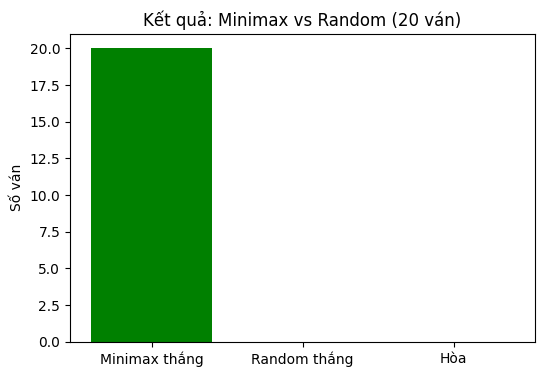

In [26]:
# Your code/ answer goes here.
# =========================================================
# PLAYTIME — Minimax vs Random Agent
# =========================================================

import time, random, matplotlib.pyplot as plt

# ------------------------------
# 1️⃣ Random Agent
# ------------------------------
def random_player(board, player=None):
    """Chọn ngẫu nhiên một nước đi hợp lệ."""
    actions = get_available_actions(board)
    if not actions:
        return None
    return random.choice(actions)


# ------------------------------
# 2️⃣ Hàm chơi giữa hai agent
# ------------------------------
def play_game(agent1, agent2, board_size=(2, 2), verbose=False, max_depth=3):
    """Cho 2 agent chơi Dots and Boxes với nhau."""
    board = initialize_board(*board_size)
    current_player = 1
    agents = {1: agent1, -1: agent2}

    while not is_terminal(board):
        agent_fn = agents[current_player]

        # --- Gọi đúng kiểu agent ---
        if agent_fn == minimax_player_with_ordering:
            move = agent_fn(board, player=current_player, max_depth=max_depth)
            action = move[0] if isinstance(move, tuple) else move

        elif agent_fn == minimax_player_heuristic:
            move = agent_fn(board, player=current_player, max_depth=max_depth)
            action = move[0] if isinstance(move, tuple) else move

        else:
            action = agent_fn(board, current_player)

        # --- Kiểm tra tính hợp lệ ---
        if action is None or not isinstance(action, tuple) or len(action) != 3:
            print(f"⚠️ Lỗi: action không hợp lệ từ {agent_fn.__name__}: {action}")
            break

        # --- Thực hiện nước đi ---
        board, next_player = result(board, action, current_player)
        current_player = next_player

        if verbose:
            print(f"\n👟 Người chơi {1 if current_player == 1 else 2} đi: {action}")
            display_board(board)
            time.sleep(0.3)

    # --- Tính kết quả ---
    u = utility(board)
    if u > 0:
        return 1
    elif u < 0:
        return -1
    else:
        return 0


# ------------------------------
# 3️⃣ Thực nghiệm: Minimax vs Random
# ------------------------------
num_games = 20   # tránh quá lâu
results = {1: 0, -1: 0, 0: 0}
start_time = time.perf_counter()

for i in range(num_games):
    outcome = play_game(
        minimax_player_heuristic,   # Player 1: Minimax heuristic
        random_player,              # Player 2: Random
        board_size=(2, 2),
        verbose=False,
        max_depth=3
    )
    results[outcome] += 1
    print(f"Ván {i+1:02d}: {'Minimax thắng' if outcome==1 else ('Random thắng' if outcome==-1 else 'Hòa')}")

elapsed = time.perf_counter() - start_time

# ------------------------------
# 4️⃣ Tổng kết kết quả
# ------------------------------
print("\n===== 🧩 TỔNG KẾT SAU", num_games, "VÁN =====")
print(f"🏆 Minimax thắng: {results[1]} ván")
print(f"🤖 Random thắng:  {results[-1]} ván")
print(f"🤝 Hòa:           {results[0]} ván")
print(f"⏱️ Tổng thời gian: {elapsed:.2f} giây")

# ------------------------------
# 5️⃣ Vẽ biểu đồ kết quả
# ------------------------------
labels = ['Minimax thắng', 'Random thắng', 'Hòa']
values = [results[1], results[-1], results[0]]

plt.figure(figsize=(6,4))
plt.bar(labels, values, color=['green', 'red', 'gray'])
plt.title("Kết quả: Minimax vs Random (20 ván)")
plt.ylabel("Số ván")
plt.show()

## Task 4: Heuristic Alpha-Beta Tree Search [30 points] 

### Heuristic evaluation function

Define and implement a heuristic evaluation function.

In [14]:
# Your code/ answer goes here.
### Heuristic Evaluation Function
import copy
import math

def count_boxes_near_completion(board, player):
    """
    Đếm số ô mà player có thể sắp hoàn thành (có 3 cạnh đã được vẽ).
    """
    near_complete = 0
    size = board['size']
    for r in range(size[0] - 1):
        for c in range(size[1] - 1):
            # 4 cạnh của ô
            edges = [
                ('h', r, c),
                ('h', r+1, c),
                ('v', r, c),
                ('v', r, c+1)
            ]
            filled = sum([(e in board['lines']) for e in edges])
            if filled == 3:
                near_complete += 1
    return near_complete


def evaluate_board(board, player):
    """
    Hàm đánh giá heuristic cho trạng thái hiện tại của bàn chơi.

    Trả về giá trị càng cao càng có lợi cho `player`.
    """
    opponent = -player

    # Số ô hoàn thành cho từng bên
    player_boxes = sum(1 for v in board['boxes'].values() if v == player)
    opponent_boxes = sum(1 for v in board['boxes'].values() if v == opponent)

    # Số ô sắp hoàn thành
    player_near = count_boxes_near_completion(board, player)
    opponent_near = count_boxes_near_completion(board, opponent)

    # Tổng số cạnh đã vẽ
    total_lines = len(board['lines'])
    max_lines = (board['size'][0] - 1) * board['size'][1] + (board['size'][1] - 1) * board['size'][0]
    progress = total_lines / max_lines  # mức độ tiến triển của ván

    # Heuristic kết hợp nhiều yếu tố
    score = (
        5 * (player_boxes - opponent_boxes) +
        2 * (player_near - opponent_near) -
        progress  # càng gần hết ván, càng giảm rủi ro
    )

    return score


# Kiểm tra hàm heuristic với một bàn nhỏ
board = initialize_board(2, 2)
draw_line(board, 'h', 0, 0)
draw_line(board, 'v', 0, 0)
draw_line(board, 'h', 1, 0)
draw_line(board, 'v', 0, 1)
board['boxes'][(0, 0)] = 1  # Giả sử người chơi 1 đã hoàn thành 1 ô

print("Đánh giá heuristic cho Player 1:", evaluate_board(board, 1))
print("Đánh giá heuristic cho Player -1:", evaluate_board(board, -1))

Đánh giá heuristic cho Player 1: 4.0
Đánh giá heuristic cho Player -1: -6.0


### Cutting off search 

Modify your Minimax Search with Alpha-Beta Pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [15]:
# Your code/ answer goes here.
### Minimax Search with Alpha-Beta Pruning + Heuristic Evaluation
import math
import copy
import time

def minimax_heuristic(board, player, depth, alpha, beta, max_depth):
    """
    Minimax với alpha-beta pruning và heuristic cutoff.

    Parameters
    ----------
    board : dict
        Trạng thái bàn chơi hiện tại
    player : int
        Người chơi hiện tại (+1 hoặc -1)
    depth : int
        Độ sâu hiện tại của tìm kiếm
    alpha, beta : float
        Các giá trị alpha, beta cho pruning
    max_depth : int
        Độ sâu tối đa (cutoff)
    """
    # Nếu là trạng thái kết thúc hoặc đạt giới hạn độ sâu → đánh giá heuristic
    if is_terminal(board) or depth >= max_depth:
        return evaluate_board(board, player), None

    best_action = None

    if player == 1:  # Max player
        value = -math.inf
        for action in get_available_actions(board):
            new_board, next_player = result(board, action, player)
            new_value, _ = minimax_heuristic(new_board, next_player, depth+1, alpha, beta, max_depth)
            if new_value > value:
                value = new_value
                best_action = action
            alpha = max(alpha, value)
            if beta <= alpha:  # Cắt nhánh
                break
        return value, best_action

    else:  # Min player (-1)
        value = math.inf
        for action in get_available_actions(board):
            new_board, next_player = result(board, action, player)
            new_value, _ = minimax_heuristic(new_board, next_player, depth+1, alpha, beta, max_depth)
            if new_value < value:
                value = new_value
                best_action = action
            beta = min(beta, value)
            if beta <= alpha:
                break
        return value, best_action


def minimax_player_heuristic(board, player=1, max_depth=3):
    """
    Agent sử dụng Minimax với heuristic cutoff.
    """
    value, action = minimax_heuristic(board, player, 0, -math.inf, math.inf, max_depth)
    return action


# ⚙️ Thử nghiệm với nhiều giá trị cutoff depth
cutoff_depths = [1, 2, 3, 4]
board = initialize_board(2, 2)
draw_line(board, 'h', 0, 0)
draw_line(board, 'v', 0, 0)

print("So sánh thời gian cho các cutoff depth khác nhau:\n")
for depth in cutoff_depths:
    start = time.time()
    value, action = minimax_heuristic(board, 1, 0, -math.inf, math.inf, max_depth=depth)
    elapsed = time.time() - start
    print(f"Depth = {depth:<2} | Action = {action} | Heuristic value = {value:.2f} | Time = {elapsed:.4f}s")

So sánh thời gian cho các cutoff depth khác nhau:

Depth = 1  | Action = ('h', 2, 0) | Heuristic value = -0.50 | Time = 0.0005s
Depth = 2  | Action = ('h', 2, 0) | Heuristic value = -0.75 | Time = 0.0011s
Depth = 3  | Action = ('h', 2, 0) | Heuristic value = -0.75 | Time = 0.0055s
Depth = 4  | Action = ('h', 2, 0) | Heuristic value = -1.00 | Time = 0.0149s


How many nodes are searched and how long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

Board (2, 2): nodes=232, time=0.0058s, best_action=('h', 2, 0), value=-0.25
Board (2, 3): nodes=464, time=0.0131s, best_action=('h', 2, 0), value=-0.14
Board (2, 4): nodes=778, time=0.0272s, best_action=('h', 2, 0), value=-0.10
Board (2, 5): nodes=1174, time=0.0447s, best_action=('h', 2, 0), value=-0.08


,Board size,Nodes searched,Time (s)
0,"(2, 2)",232,0.005763
1,"(2, 3)",464,0.013089
2,"(2, 4)",778,0.027158
3,"(2, 5)",1174,0.044748


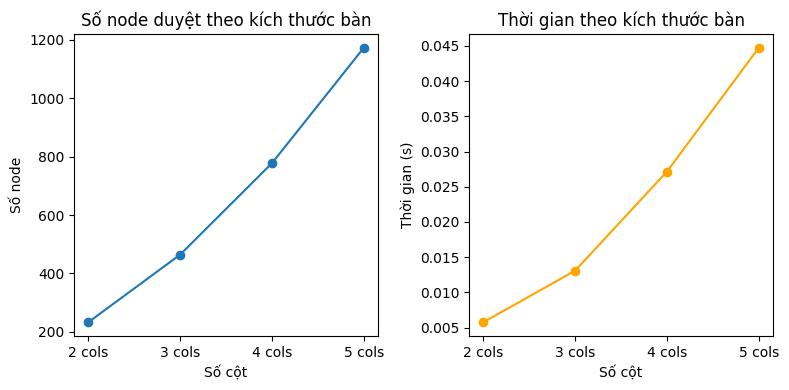

In [16]:
# Your code/ answer goes here.
### 🧮 Hiệu suất tìm kiếm: Số node và thời gian với các kích thước bàn khác nhau

import time
import math
import copy

# Biến toàn cục để đếm số node đã duyệt trong mỗi lần chạy
node_counter = 0

def minimax_heuristic_count(board, player, depth, alpha, beta, max_depth):
    """
    Minimax với Alpha-Beta Pruning + Heuristic Evaluation + Đếm node.
    """
    global node_counter
    node_counter += 1  # mỗi khi gọi là duyệt 1 node

    # Điều kiện dừng
    if is_terminal(board) or depth >= max_depth:
        return evaluate_board(board, player), None

    best_action = None

    if player == 1:  # Max player
        value = -math.inf
        for action in get_available_actions(board):
            new_board, next_player = result(board, action, player)
            new_value, _ = minimax_heuristic_count(new_board, next_player, depth+1, alpha, beta, max_depth)
            if new_value > value:
                value = new_value
                best_action = action
            alpha = max(alpha, value)
            if beta <= alpha:
                break
        return value, best_action

    else:  # Min player (-1)
        value = math.inf
        for action in get_available_actions(board):
            new_board, next_player = result(board, action, player)
            new_value, _ = minimax_heuristic_count(new_board, next_player, depth+1, alpha, beta, max_depth)
            if new_value < value:
                value = new_value
                best_action = action
            beta = min(beta, value)
            if beta <= alpha:
                break
        return value, best_action


# 🧩 Thử nghiệm với bàn tăng dần về kích thước (số cột)
board_sizes = [(2, 2), (2, 3), (2, 4), (2, 5)]  # tăng dần cột
max_depth = 3  # độ sâu cố định để so sánh
results = []

for size in board_sizes:
    board = initialize_board(*size)
    start_time = time.time()
    node_counter = 0  # reset bộ đếm
    value, action = minimax_heuristic_count(board, player=1, depth=0, alpha=-math.inf, beta=math.inf, max_depth=max_depth)
    elapsed = time.time() - start_time
    results.append((size, node_counter, elapsed))
    print(f"Board {size}: nodes={node_counter}, time={elapsed:.4f}s, best_action={action}, value={value:.2f}")

# 📊 Hiển thị kết quả dạng bảng
import pandas as pd

df = pd.DataFrame(results, columns=["Board size", "Nodes searched", "Time (s)"])
display(df)

# 📈 Biểu đồ trực quan hóa
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot([f"{r[0][1]} cols" for r in results], [r[1] for r in results], marker='o')
plt.title("Số node duyệt theo kích thước bàn")
plt.xlabel("Số cột")
plt.ylabel("Số node")

plt.subplot(1,2,2)
plt.plot([f"{r[0][1]} cols" for r in results], [r[2] for r in results], marker='o', color='orange')
plt.title("Thời gian theo kích thước bàn")
plt.xlabel("Số cột")
plt.ylabel("Thời gian (s)")

plt.tight_layout()
plt.show()

### Playtime

Let two heuristic search agents (different cutoff depth, different heuristic evaluation function) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

In [19]:
# Your code/ answer goes here.
### 🤖 So tài giữa hai Heuristic Agents (khác cutoff depth & heuristic)

import math
import random
import time
import copy

# --------------------------------------------------------------
# 1️⃣ HÀM KHỞI TẠO BÀN CỜ
# --------------------------------------------------------------
def initialize_board(rows, cols):
    return {
        'size': (rows, cols),
        'lines': dict(),
        'boxes': dict()
    }

# --------------------------------------------------------------
# 2️⃣ HÀM VẼ ĐƯỜNG (line)
# --------------------------------------------------------------
def draw_line(board, orientation, row, col):
    if orientation not in ['h', 'v']:
        return False
    if (orientation, row, col) in board['lines']:
        return False
    board['lines'][(orientation, row, col)] = True
    return True

# --------------------------------------------------------------
# 3️⃣ HIỂN THỊ BÀN CỜ TRÊN TERMINAL
# --------------------------------------------------------------
def display_board(board):
    rows, cols = board['size']
    lines = board['lines']
    boxes = board['boxes']

    for r in range(rows + 1):
        # hàng ngang
        line_str = ""
        for c in range(cols + 1):
            line_str += "•"
            if c < cols:
                if ('h', r, c) in lines:
                    line_str += "---"
                else:
                    line_str += "   "
        print(line_str)

        # hàng dọc + hộp
        if r < rows:
            line_str = ""
            for c in range(cols + 1):
                if ('v', r, c) in lines:
                    line_str += "|"
                else:
                    line_str += " "
                if c < cols:
                    if (r, c) in boxes:
                        line_str += f" {1 if boxes[(r,c)]==1 else 2} "
                    else:
                        line_str += "   "
            print(line_str)

# --------------------------------------------------------------
# 4️⃣ KIỂM TRA Ô HOÀN THÀNH
# --------------------------------------------------------------
def check_completed_boxes(board, player):
    rows, cols = board['size']
    completed = 0
    for r in range(rows):
        for c in range(cols):
            if all((
                ('h', r, c) in board['lines'],
                ('h', r+1, c) in board['lines'],
                ('v', r, c) in board['lines'],
                ('v', r, c+1) in board['lines']
            )):
                if (r, c) not in board['boxes']:
                    board['boxes'][(r, c)] = player
                    completed += 1
    return completed

# --------------------------------------------------------------
# 5️⃣ TÌM HÀNH ĐỘNG HỢP LỆ
# --------------------------------------------------------------
def get_available_actions(board):
    actions = []
    rows, cols = board['size']

    # ngang
    for r in range(rows + 1):
        for c in range(cols):
            if ('h', r, c) not in board['lines']:
                actions.append(('h', r, c))
    # dọc
    for r in range(rows):
        for c in range(cols + 1):
            if ('v', r, c) not in board['lines']:
                actions.append(('v', r, c))
    return actions

# --------------------------------------------------------------
# 6️⃣ KIỂM TRA TRẠNG THÁI CUỐI
# --------------------------------------------------------------
def is_terminal(board):
    total_lines = (board['size'][0] + 1) * board['size'][1] + (board['size'][1] + 1) * board['size'][0]
    return len(board['lines']) >= total_lines

# --------------------------------------------------------------
# 7️⃣ HÀM KẾT QUẢ (SAU MỘT NƯỚC ĐI)
# --------------------------------------------------------------
def result(board, action, player):
    new_board = copy.deepcopy(board)
    draw_line(new_board, *action)
    completed = check_completed_boxes(new_board, player)
    next_player = player if completed > 0 else -player
    return new_board, next_player

# --------------------------------------------------------------
# 8️⃣ HÀM LỢI ÍCH (UTILITY)
# --------------------------------------------------------------
def utility(board):
    p1 = sum(1 for v in board['boxes'].values() if v == 1)
    p2 = sum(1 for v in board['boxes'].values() if v == -1)
    return p1 - p2

# --------------------------------------------------------------
# 9️⃣ HÀM HEURISTIC (2 biến thể khác nhau)
# --------------------------------------------------------------
def evaluate_board(board, player):
    """Heuristic nâng cao: tính chênh lệch số ô và phạt ô sắp bị mất"""
    rows, cols = board['size']
    opponent = -player
    my_boxes = sum(1 for v in board['boxes'].values() if v == player)
    opp_boxes = sum(1 for v in board['boxes'].values() if v == opponent)

    # Điểm thưởng khi có ô sắp hoàn thành
    potential = 0
    for r in range(rows):
        for c in range(cols):
            sides = sum([
                ('h', r, c) in board['lines'],
                ('h', r+1, c) in board['lines'],
                ('v', r, c) in board['lines'],
                ('v', r, c+1) in board['lines']
            ])
            if sides == 3:
                potential += 0.5 if player == 1 else -0.5

    return (my_boxes - opp_boxes) + potential

def evaluate_board_simple(board, player):
    """Heuristic đơn giản"""
    opponent = -player
    my_boxes = sum(1 for v in board['boxes'].values() if v == player)
    opp_boxes = sum(1 for v in board['boxes'].values() if v == opponent)
    return my_boxes - opp_boxes

# --------------------------------------------------------------
# 🔟 MINIMAX VỚI ALPHA-BETA + CUTOFF + HEURISTIC
# --------------------------------------------------------------
def minimax_heuristic_custom(board, player, depth, alpha, beta, max_depth, eval_fn):
    if is_terminal(board) or depth >= max_depth:
        return eval_fn(board, player), None

    best_action = None
    if player == 1:
        value = -math.inf
        for action in get_available_actions(board):
            new_board, next_player = result(board, action, player)
            new_value, _ = minimax_heuristic_custom(new_board, next_player, depth+1, alpha, beta, max_depth, eval_fn)
            if new_value > value:
                value = new_value
                best_action = action
            alpha = max(alpha, value)
            if beta <= alpha:
                break
        return value, best_action
    else:
        value = math.inf
        for action in get_available_actions(board):
            new_board, next_player = result(board, action, player)
            new_value, _ = minimax_heuristic_custom(new_board, next_player, depth+1, alpha, beta, max_depth, eval_fn)
            if new_value < value:
                value = new_value
                best_action = action
            beta = min(beta, value)
            if beta <= alpha:
                break
        return value, best_action

def heuristic_agent(board, player=1, max_depth=3, eval_fn=evaluate_board):
    _, action = minimax_heuristic_custom(board, player, 0, -math.inf, math.inf, max_depth, eval_fn)
    return action

# --------------------------------------------------------------
# 1️⃣1️⃣ MÔI TRƯỜNG CHƠI GAME
# --------------------------------------------------------------
def play_game(agent1, agent2, board_size=(2,4), verbose=True):
    board = initialize_board(*board_size)
    current_player = 1
    step = 0

    while not is_terminal(board):
        step += 1
        if current_player == 1:
            action = agent1(board, player=1)
        else:
            action = agent2(board, player=-1)

        if action is None:
            break

        board, next_player = result(board, action, current_player)

        if verbose:
            print(f"\n🔹 Turn {step} — Player {1 if current_player == 1 else 2}: {action}")
            display_board(board)
            print("-"*40)

        current_player = next_player

    util = utility(board)
    if util > 0:
        winner = "Player 1"
    elif util < 0:
        winner = "Player 2"
    else:
        winner = "Tie"

    print(f"\n🏁 Kết thúc trận đấu — Winner: {winner}, Utility: {util}")
    return winner

# --------------------------------------------------------------
# 1️⃣2️⃣ CHẠY THỬ: 2 HEURISTIC AGENTS ĐẤU NHAU
# --------------------------------------------------------------
agent_1 = lambda b, player=1: heuristic_agent(b, player=player, max_depth=4, eval_fn=evaluate_board)
agent_2 = lambda b, player=-1: heuristic_agent(b, player=player, max_depth=2, eval_fn=evaluate_board_simple)

winner = play_game(agent_1, agent_2, board_size=(2, 3), verbose=True)


🔹 Turn 1 — Player 1: ('h', 0, 0)
•---•   •   •
             
•   •   •   •
             
•   •   •   •
----------------------------------------

🔹 Turn 2 — Player 2: ('h', 0, 1)
•---•---•   •
             
•   •   •   •
             
•   •   •   •
----------------------------------------

🔹 Turn 3 — Player 1: ('h', 1, 0)
•---•---•   •
             
•---•   •   •
             
•   •   •   •
----------------------------------------

🔹 Turn 4 — Player 2: ('h', 0, 2)
•---•---•---•
             
•---•   •   •
             
•   •   •   •
----------------------------------------

🔹 Turn 5 — Player 1: ('h', 1, 1)
•---•---•---•
             
•---•---•   •
             
•   •   •   •
----------------------------------------

🔹 Turn 6 — Player 2: ('h', 1, 2)
•---•---•---•
             
•---•---•---•
             
•   •   •   •
----------------------------------------

🔹 Turn 7 — Player 1: ('h', 2, 0)
•---•---•---•
             
•---•---•---•
             
•---•   •   •
--------------------------

## Tournament task [+1 to 5% bonus on your course grade; will be assigned separately]

Find another student and let your best agent play against the other student's best player. You are allowed to use any improvements you like as long as you code it yourself. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [10 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+5 Bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search (see [tic-tac-toe-example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_pure_monte_carlo_search.ipynb)) and investigate how this search performs on the test boards that you have used above. 

In [20]:
# Your code/ answer goes here.
### 🏆 Tournament Task + 🎲 Pure Monte Carlo Search (Bonus Task)

import random
import time
import copy

# ==========================================================
# 🎯 Pure Monte Carlo Search Agent
# ==========================================================
def random_simulation(board, current_player):
    """
    Chạy mô phỏng ngẫu nhiên cho đến hết ván và trả về utility cuối cùng.
    """
    sim_board = copy.deepcopy(board)
    player = current_player

    while not is_terminal(sim_board):
        actions = get_available_actions(sim_board)
        if not actions:
            break
        action = random.choice(actions)
        sim_board, next_player = result(sim_board, action, player)
        player = next_player

    return utility(sim_board)


def monte_carlo_action(board, player=1, simulations=100):
    """
    Pure Monte Carlo Search:
    Với mỗi hành động có thể, chạy một số lượng mô phỏng ngẫu nhiên (rollouts)
    và chọn hành động có kết quả trung bình cao nhất.
    """
    actions = get_available_actions(board)
    if not actions:
        return None

    best_action = None
    best_value = -float('inf') if player == 1 else float('inf')

    for action in actions:
        total = 0
        for _ in range(simulations):
            new_board, next_player = result(board, action, player)
            total += random_simulation(new_board, next_player)

        avg_value = total / simulations

        if player == 1:
            if avg_value > best_value:
                best_value = avg_value
                best_action = action
        else:
            if avg_value < best_value:
                best_value = avg_value
                best_action = action

    return best_action


def monte_carlo_agent(board, player=1, simulations=50):
    """
    Agent Monte Carlo cơ bản với số lượng mô phỏng giới hạn.
    """
    return monte_carlo_action(board, player, simulations)


# ==========================================================
# 🧪 Kiểm tra: Monte Carlo vs Heuristic Agent
# ==========================================================

def play_game(agent1, agent2, board_size=(2,3), verbose=False):
    """
    Cho hai agent đấu với nhau.
    """
    board = initialize_board(*board_size)
    current_player = 1

    while not is_terminal(board):
        if current_player == 1:
            action = agent1(board, player=1)
        else:
            action = agent2(board, player=-1)

        if action is None:
            break

        board, next_player = result(board, action, current_player)
        current_player = next_player

    util = utility(board)
    if util > 0:
        winner = "Player 1"
    elif util < 0:
        winner = "Player 2"
    else:
        winner = "Tie"

    if verbose:
        display_board(board)
        print(f"🏁 Winner: {winner}, Utility: {util}")

    return winner


# Cấu hình agents:
# - Agent 1: Monte Carlo
# - Agent 2: Heuristic Alpha-Beta (depth = 3)
agent_montecarlo = lambda b, player=1: monte_carlo_agent(b, player=player, simulations=40)
agent_heuristic = lambda b, player=-1: heuristic_agent(b, player=player, max_depth=3, eval_fn=evaluate_board)

# Chơi 5 ván tượng trưng để so sánh
results = {"MonteCarlo": 0, "Heuristic": 0, "Tie": 0}

for i in range(5):
    print(f"\n🎮 Game {i+1}")
    winner = play_game(agent_montecarlo, agent_heuristic, board_size=(2, 3), verbose=False)
    if winner == "Player 1":
        results["MonteCarlo"] += 1
    elif winner == "Player 2":
        results["Heuristic"] += 1
    else:
        results["Tie"] += 1

print("\n📊 Kết quả sau 5 trận:")
for k, v in results.items():
    print(f"{k}: {v}")


🎮 Game 1

🎮 Game 2

🎮 Game 3

🎮 Game 4

🎮 Game 5

📊 Kết quả sau 5 trận:
MonteCarlo: 0
Heuristic: 2
Tie: 3


### Best First Move

How would you determine what the best first move for a standard board ($5 \times 5$) is? You can use Pure Monte Carlo Search or any algorithms that you have implemented above.

In [21]:
# Your code/ answer goes here.
import random
import time
import copy
import math

# ---------------------------------------------------------------
# Hàm khởi tạo bàn cờ
# ---------------------------------------------------------------
def initialize_board(rows, cols):
    return {'size': (rows, cols), 'lines': dict(), 'boxes': dict()}

# ---------------------------------------------------------------
# Các hàm hỗ trợ từ phần trước (rút gọn)
# ---------------------------------------------------------------
def draw_line(board, orientation, row, col):
    if (orientation, row, col) in board['lines']:
        return False
    board['lines'][(orientation, row, col)] = True
    return True

def get_available_actions(board):
    actions = []
    rows, cols = board['size']
    for r in range(rows + 1):
        for c in range(cols):
            if ('h', r, c) not in board['lines']:
                actions.append(('h', r, c))
    for r in range(rows):
        for c in range(cols + 1):
            if ('v', r, c) not in board['lines']:
                actions.append(('v', r, c))
    return actions

def check_completed_boxes(board, player):
    rows, cols = board['size']
    completed = 0
    for r in range(rows):
        for c in range(cols):
            if all((
                ('h', r, c) in board['lines'],
                ('h', r+1, c) in board['lines'],
                ('v', r, c) in board['lines'],
                ('v', r, c+1) in board['lines']
            )):
                if (r, c) not in board['boxes']:
                    board['boxes'][(r, c)] = player
                    completed += 1
    return completed

def result(board, action, player):
    new_board = copy.deepcopy(board)
    draw_line(new_board, *action)
    completed = check_completed_boxes(new_board, player)
    next_player = player if completed > 0 else -player
    return new_board, next_player

def is_terminal(board):
    rows, cols = board['size']
    total_lines = (rows + 1) * cols + (cols + 1) * rows
    return len(board['lines']) == total_lines

def utility(board):
    p1 = sum(1 for v in board['boxes'].values() if v == 1)
    p2 = sum(1 for v in board['boxes'].values() if v == -1)
    return p1 - p2

# ---------------------------------------------------------------
# Pure Monte Carlo Search
# ---------------------------------------------------------------
def monte_carlo_simulation(board, action, player, num_simulations=30):
    """
    Chạy mô phỏng ngẫu nhiên sau khi chọn action nhất định.
    Trả về giá trị trung bình (utility) từ góc nhìn của người chơi ban đầu.
    """
    total_score = 0
    for _ in range(num_simulations):
        sim_board, sim_player = result(board, action, player)
        
        # Mô phỏng ngẫu nhiên đến hết trận
        while not is_terminal(sim_board):
            available = get_available_actions(sim_board)
            if not available:
                break
            random_action = random.choice(available)
            sim_board, sim_player = result(sim_board, random_action, sim_player)
        
        total_score += utility(sim_board)
    
    return total_score / num_simulations

# ---------------------------------------------------------------
# Tìm nước đi đầu tiên tốt nhất bằng Monte Carlo
# ---------------------------------------------------------------
def best_first_move_montecarlo(board, player=1, num_simulations=30):
    actions = get_available_actions(board)
    results = {}
    print(f"🔎 Đang chạy Monte Carlo cho {len(actions)} hành động...")

    for action in actions:
        avg_score = monte_carlo_simulation(board, action, player, num_simulations)
        results[action] = avg_score
    
    # Sắp xếp theo điểm trung bình
    best_action = max(results, key=results.get)
    print(f"\n✅ Nước đi đầu tiên tốt nhất: {best_action} (Điểm trung bình = {results[best_action]:.2f})")
    return best_action, results

# ---------------------------------------------------------------
# Thực nghiệm: Bàn chuẩn 5x5
# ---------------------------------------------------------------
start_time = time.time()
board = initialize_board(5, 5)
best_move, results = best_first_move_montecarlo(board, player=1, num_simulations=20)
end_time = time.time()

# Hiển thị kết quả
print("\n🕒 Thời gian thực hiện:", round(end_time - start_time, 2), "giây")
print("\nTop 5 nước đi có điểm cao nhất:")
sorted_moves = sorted(results.items(), key=lambda x: x[1], reverse=True)[:5]
for move, score in sorted_moves:
    print(f"{move} → {score:.3f}")

🔎 Đang chạy Monte Carlo cho 60 hành động...

✅ Nước đi đầu tiên tốt nhất: ('v', 0, 2) (Điểm trung bình = 4.40)

🕒 Thời gian thực hiện: 8.8 giây

Top 5 nước đi có điểm cao nhất:
('v', 0, 2) → 4.400
('h', 2, 0) → 3.700
('h', 1, 1) → 3.600
('v', 1, 2) → 3.600
('v', 3, 2) → 3.500
